[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab1-NetworkSci-PSN/notebooks/04a-patient_similarity_network_IQ_solutions.ipynb)


# 🔑 Solutions: Patient Similarity Network Based on WAIS-IV

Last updated: 2025-12-21, A. Lundervold

This notebook contains **solutions** to the exercises in `04-patient_similarity_network_IQ.ipynb`.

> 📋 **Clinical foundation**: The solutions are informed by [*Guidelines in Clinical Neuropsychology*](https://nevropsyk.org) (NNF, 2024), which describes principles for responsible practice of clinical neuropsychological work in Norway.

---

## 📋 Contents

1. [Setup and preparations](#1-oppsett)
2. [Exploratory Data Analysis (EDA)](#eda) ← **Important first step!**
3. [Task 1: Changing parameters (k_nearest)](#oppgave-1)
4. [Task 2: Age effects in PSN](#oppgave-2)
5. [Task 3: Subtest contributions to communities](#oppgave-3)
6. [Task 4: NNF qualitative descriptors](#oppgave-4)
7. [Task 5: Similarity measures and variable types](#oppgave-5) ⭐ **New!**
8. [Reflection questions with discussions](#refleksjon)

---

> 💡 **Tip**: Run through the main notebook first to understand the context. This solution notebook builds on the code and data from there.


<a id="1-oppsett"></a>
## 1. Setup and preparations

First, we load the necessary libraries and data from the main notebook.

> 📝 **Note about the simulation**: The average FSIQ in the sample is ≈97 (not 100). This is **expected** and is because we simulate age-related cognitive decline without applying age normalization. In real WAIS-IV, all scores would be age-normalized (μ=100). See the main notebook (section 2.1) for a full explanation of why this is acceptable for PSN purposes.


In [1]:
# ============================================================================
# IMPORT AND SETUP
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy.spatial.distance import pdist, squareform
from scipy import stats
from sklearn.preprocessing import StandardScaler
import warnings

# Community detection
try:
    import community.community_louvain as community_louvain
    COMMUNITY_AVAILABLE = True
except ImportError:
    print("⚠️ python-louvain not installed. Install with: pip install python-louvain")
    COMMUNITY_AVAILABLE = False

# Visual settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 11
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(2025)

print("✓ Libraries loaded!")


✓ Libraries loaded!


In [2]:
# ============================================================================
# WAIS-IV STRUCTURE AND HELPER FUNCTIONS
# ============================================================================

# WAIS-IV test structure (core subtests)
WAIS_STRUCTURE = {
    'VCI': ['Vocabulary', 'Similarities', 'Information'],
    'WMI': ['Digit_Span', 'Arithmetic'],
    'PRI': ['Block_Design', 'Matrix_Reasoning', 'Visual_Puzzles'],
    'PSI': ['Symbol_Search', 'Coding']
}

VIQ_INDICES = ['VCI', 'WMI']
PIQ_INDICES = ['PRI', 'PSI']

ALL_SUBTESTS = []

# --- NNF Qualitative descriptors (Guidelines in Clinical Neuropsychology, 2024, Appendix 3) ---
def nnf_qualitative_descriptor_index(score):
    """
    Classify index score (μ=100, σ=15) according to NNF guidelines.
    
    Reference: Norwegian Neuropsychological Association (2024). Guidelines in Clinical 
    Neuropsychology, Appendix 3: Qualitative descriptors for normally distributed scores.
    """
    if score >= 130:
        return 'Very High'
    elif score >= 120:
        return 'High'
    elif score >= 110:
        return 'High Average'
    elif score >= 90:
        return 'Average'
    elif score >= 80:
        return 'Low Average'
    elif score >= 70:
        return 'Low (Borderline)'
    else:
        return 'Very Low'

def nnf_qualitative_descriptor_subtest(score):
    """
    Classify subtest score (μ=10, σ=3) according to NNF guidelines.
    """
    if score >= 16:
        return 'Very High'
    elif score >= 14:
        return 'High'
    elif score >= 12:
        return 'High Average'
    elif score >= 8:
        return 'Average'
    elif score >= 6:
        return 'Low Average'
    elif score >= 4:
        return 'Low (Borderline)'
    else:
        return 'Very Low'
for index, subtests in WAIS_STRUCTURE.items():
    ALL_SUBTESTS.extend(subtests)


def create_similarity_matrix(data, metric='euclidean'):
    """
    Compute similarity matrix from feature matrix.
    
    Process:
    1. Standardize data (z-scores) → all variables contribute equally
    2. Compute Euclidean distance between all pairs
    3. Convert distance → similarity with Gaussian kernel: s = exp(-d²/2σ²)
    
    Note: Choice of distance measure and kernel function affects the result!
    - Euclidean: Patients with similar LEVEL and PROFILE are alike
    - Cosine: Only PROFILE (ignores absolute level)
    See main notebook (section 3.1) for full discussion.
    """
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(data)
    distances = pdist(scaled_data, metric=metric)
    dist_matrix = squareform(distances)
    sigma = np.mean(distances) + 1e-8  # Adaptive bandwidth
    similarity_matrix = np.exp(-dist_matrix**2 / (2 * sigma**2))
    return similarity_matrix


def create_psn(similarity_matrix, k_nearest=10):
    """Build patient similarity network from similarity matrix."""
    n = similarity_matrix.shape[0]
    G = nx.Graph()
    G.add_nodes_from(range(n))
    
    for i in range(n):
        neighbors = np.argsort(similarity_matrix[i])[-k_nearest-1:-1]
        for j in neighbors:
            if i != j:
                weight = similarity_matrix[i, j]
                G.add_edge(i, j, weight=weight)
    return G


def detect_communities(G):
    """Perform community detection using the Louvain method."""
    if COMMUNITY_AVAILABLE:
        partition = community_louvain.best_partition(G)
        modularity = community_louvain.modularity(partition, G)
    else:
        communities = nx.community.greedy_modularity_communities(G)
        partition = {}
        for i, comm in enumerate(communities):
            for node in comm:
                partition[node] = i
        modularity = nx.community.modularity(G, communities)
    return partition, modularity


print("✓ Helper functions defined!")


✓ Helper functions defined!


In [4]:
# ============================================================================
# LOAD DATA
# ============================================================================

# First try to load from file, otherwise simulate new data
try:
    df = pd.read_csv('../data/wais4_simulated_data.csv')
    print(f"✓ Loaded data from file: {len(df)} individuals")
except FileNotFoundError:
    print("⚠️ Data file not found. Simulating new data...")
    
    # Simulation function (simplified version)
    def simulate_wais4_data(n_individuals=500, seed=2025):
        np.random.seed(seed)
        
        age = np.clip(np.random.normal(45, 15, n_individuals), 16, 90).astype(int)
        gender = np.random.choice(['M', 'F'], n_individuals)
        education = np.random.choice([1, 2, 3, 4, 5], n_individuals, 
                                      p=[0.10, 0.25, 0.35, 0.20, 0.10])
        
        g_factor = np.random.normal(0, 1, n_individuals)
        domain_factors = {idx: np.random.normal(0, 1, n_individuals) 
                          for idx in ['VCI', 'WMI', 'PRI', 'PSI']}
        
        item_scores = {}
        for index, subtests in WAIS_STRUCTURE.items():
            for subtest in subtests:
                raw = 0.6*g_factor + 0.5*domain_factors[index] + 0.3*np.random.normal(0, 1, n_individuals)
                item_scores[subtest] = np.clip(10 + 3*raw, 1, 19).astype(int)
        
        # Age effects
        age_effect = (age - 45) / 45
        for s in WAIS_STRUCTURE['PSI']:
            item_scores[s] = np.clip(item_scores[s] - (2*age_effect).astype(int), 1, 19)
        for s in WAIS_STRUCTURE['WMI']:
            item_scores[s] = np.clip(item_scores[s] - (1*age_effect).astype(int), 1, 19)
        
        # Education effect
        edu_effect = (education - 3) * 0.5
        for s in WAIS_STRUCTURE['VCI']:
            item_scores[s] = np.clip(item_scores[s] + edu_effect.astype(int), 1, 19)
        
        # Index scores
        index_scores = {}
        for index, subtests in WAIS_STRUCTURE.items():
            mean_score = np.mean([item_scores[s] for s in subtests], axis=0)
            index_scores[index] = np.clip(100 + 15*(mean_score - 10)/3, 40, 160).astype(int)
        
        VIQ = np.clip(100 + 15*np.mean([(index_scores[i]-100)/15 for i in VIQ_INDICES], axis=0), 40, 160).astype(int)
        PIQ = np.clip(100 + 15*np.mean([(index_scores[i]-100)/15 for i in PIQ_INDICES], axis=0), 40, 160).astype(int)
        FSIQ = np.clip(100 + 15*np.mean([(VIQ-100)/15, (PIQ-100)/15], axis=0), 40, 160).astype(int)
        
        data = {'ID': [f'P{str(i+1).zfill(4)}' for i in range(n_individuals)],
                'Age': age, 'Gender': gender, 'Education': education}
        data.update(item_scores)
        data.update(index_scores)
        data.update({'VIQ': VIQ, 'PIQ': PIQ, 'FSIQ': FSIQ})
        
        return pd.DataFrame(data)
    
    df = simulate_wais4_data(500)
    print(f"✓ Simulated {len(df)} individuals")

# Show overview
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst rows:")
df.head()


✓ Loaded data from file: 500 individuals

Columns: ['ID', 'Age', 'Gender', 'Education', 'Vocabulary', 'Similarities', 'Information', 'Digit_Span', 'Arithmetic', 'Block_Design', 'Matrix_Reasoning', 'Visual_Puzzles', 'Symbol_Search', 'Coding', 'VCI', 'WMI', 'PRI', 'PSI', 'VIQ', 'PIQ', 'FSIQ']

First rows:


,ID,Age,Gender,Education,Vocabulary,Similarities,Information,Digit_Span,Arithmetic,Block_Design,...,Visual_Puzzles,Symbol_Search,Coding,VCI,WMI,PRI,PSI,VIQ,PIQ,FSIQ
0,P0001,43,F,3,7,7,9,12,9,10,...,10,11,11,88,102,100,105,95,102,98
1,P0002,56,M,2,15,15,15,12,13,15,...,13,12,12,125,112,118,110,118,114,116
2,P0003,23,F,4,11,12,11,10,11,14,...,13,11,10,106,102,118,102,104,110,107
3,P0004,35,M,5,13,14,14,14,14,13,...,13,15,12,118,120,115,117,119,116,117
4,P0005,43,F,4,6,8,8,7,6,9,...,10,14,11,86,82,98,112,84,105,94


<a id="eda"></a>
## 2. Exploratory Data Analysis (EDA)

> 🎓 **Pedagogical point**: Before we tackle specific analyses, we should always do a thorough EDA. This is good practice because:
> 1. We discover any data errors or missing values
> 2. We understand the data structure and distributions
> 3. We identify potential patterns and outliers
> 4. We verify that the simulation has produced expected results

### 2.1 Basic data overview


In [5]:
# ============================================================================
# EDA STEP 1: Basic data overview
# ============================================================================

print("="*70)
print("BASIC DATA OVERVIEW")
print("="*70)

# Dimensions
print(f"\n📊 Dataset dimensions: {df.shape[0]} rows × {df.shape[1]} columns")

# Column types
print(f"\n📋 Columns ({len(df.columns)} total):")
print(f"   • Demographic: ID, Age, Gender, Education")
print(f"   • Subtests ({len(ALL_SUBTESTS)}): {', '.join(ALL_SUBTESTS)}")
print(f"   • Indices: VCI, WMI, PRI, PSI")
print(f"   • Composite: VIQ, PIQ, FSIQ")

# Missing values
print(f"\n❓ Missing values:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("   ✓ No missing values!")
else:
    print(missing[missing > 0])

# Data types
print(f"\n🔢 Data types:")
print(df.dtypes.value_counts())

# First and last rows
print("\n📄 First 3 rows:")
df.head(3)


BASIC DATA OVERVIEW

📊 Dataset dimensions: 500 rows × 21 columns

📋 Columns (21 total):
   • Demographic: ID, Age, Gender, Education
   • Subtests (10): Vocabulary, Similarities, Information, Digit_Span, Arithmetic, Block_Design, Matrix_Reasoning, Visual_Puzzles, Symbol_Search, Coding
   • Indices: VCI, WMI, PRI, PSI
   • Composite: VIQ, PIQ, FSIQ

❓ Missing values:
   ✓ No missing values!

🔢 Data types:
int64     19
object     2
Name: count, dtype: int64

📄 First 3 rows:


,ID,Age,Gender,Education,Vocabulary,Similarities,Information,Digit_Span,Arithmetic,Block_Design,...,Visual_Puzzles,Symbol_Search,Coding,VCI,WMI,PRI,PSI,VIQ,PIQ,FSIQ
0,P0001,43,F,3,7,7,9,12,9,10,...,10,11,11,88,102,100,105,95,102,98
1,P0002,56,M,2,15,15,15,12,13,15,...,13,12,12,125,112,118,110,118,114,116
2,P0003,23,F,4,11,12,11,10,11,14,...,13,11,10,106,102,118,102,104,110,107


### 2.2 Descriptive statistics

#### Demographic variables


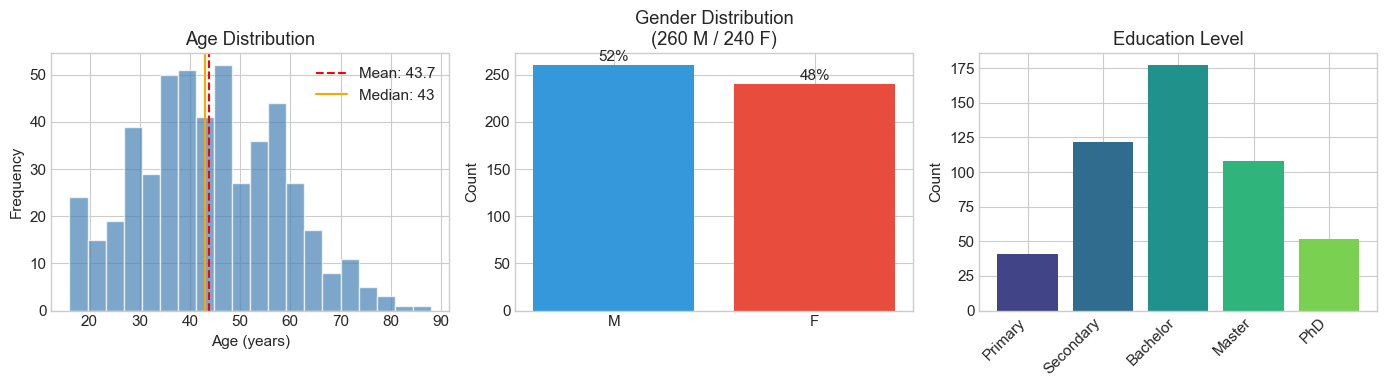


Demographic summary:
  • Age: M = 43.7, SD = 14.3, range = [16-88]
  • Gender: 52% male, 48% female
  • Education: Median = 3 (Bachelor)


In [6]:
# ============================================================================
# EDA STEP 2: Demographic variables
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Age distribution
ax1 = axes[0]
ax1.hist(df['Age'], bins=20, color='steelblue', edgecolor='white', alpha=0.7)
ax1.axvline(df['Age'].mean(), color='red', linestyle='--', label=f'Mean: {df["Age"].mean():.1f}')
ax1.axvline(df['Age'].median(), color='orange', linestyle='-', label=f'Median: {df["Age"].median():.0f}')
ax1.set_xlabel('Age (years)')
ax1.set_ylabel('Frequency')
ax1.set_title('Age Distribution')
ax1.legend()

# Gender distribution
ax2 = axes[1]
gender_counts = df['Gender'].value_counts()
ax2.bar(gender_counts.index, gender_counts.values, color=['#3498db', '#e74c3c'])
ax2.set_ylabel('Count')
ax2.set_title(f'Gender Distribution\n({gender_counts["M"]} M / {gender_counts["F"]} F)')
for i, v in enumerate(gender_counts.values):
    ax2.text(i, v + 5, f'{v/len(df)*100:.0f}%', ha='center')

# Education distribution
ax3 = axes[2]
edu_labels = {1: 'Primary', 2: 'Secondary', 3: 'Bachelor', 4: 'Master', 5: 'PhD'}
edu_counts = df['Education'].value_counts().sort_index()
colors = plt.cm.viridis(np.linspace(0.2, 0.8, 5))
ax3.bar([edu_labels[i] for i in edu_counts.index], edu_counts.values, color=colors)
ax3.set_ylabel('Count')
ax3.set_title('Education Level')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("\nDemographic summary:")
print(f"  • Age: M = {df['Age'].mean():.1f}, SD = {df['Age'].std():.1f}, range = [{df['Age'].min()}-{df['Age'].max()}]")
print(f"  • Gender: {gender_counts['M']/len(df)*100:.0f}% male, {gender_counts['F']/len(df)*100:.0f}% female")
print(f"  • Education: Median = {df['Education'].median():.0f} ({edu_labels[int(df['Education'].median())]})")


#### Cognitive scores (indices and FSIQ)


In [7]:
# ============================================================================
# EDA STEP 3: Cognitive scores
# ============================================================================

# Descriptive statistics for indices
index_cols = ['VCI', 'WMI', 'PRI', 'PSI', 'VIQ', 'PIQ', 'FSIQ']

print("="*70)
print("DESCRIPTIVE STATISTICS FOR COGNITIVE SCORES")
print("="*70)

# Summary table
summary = df[index_cols].describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]
summary.columns = ['M', 'SD', 'Min', 'P25', 'Median', 'P75', 'Max']
print("\n" + summary.round(1).to_string())

# Check against expected values
print("\n" + "="*70)
print("COMPARISON WITH EXPECTED POPULATION VALUES")
print("="*70)
print(f"\n{'Variable':<10} {'Sample M':>10} {'Population μ':>15} {'Deviation':>10} {'Sample SD':>10} {'Pop. σ':>10}")
print("-"*70)
for col in ['VCI', 'WMI', 'PRI', 'PSI', 'FSIQ']:
    m = df[col].mean()
    sd = df[col].std()
    deviation = m - 100
    print(f"{col:<10} {m:>10.1f} {100:>15} {deviation:>+10.1f} {sd:>10.1f} {15:>10}")

print("\n⚠️ Observation: All means are below 100 (expected due to lack of age normalization)")


DESCRIPTIVE STATISTICS FOR COGNITIVE SCORES

         M    SD   Min   P25  Median    P75    Max
VCI   98.0  12.6  55.0  90.0    98.0  106.0  135.0
WMI   97.6  12.5  62.0  90.0    97.0  107.0  135.0
PRI   97.1  11.8  58.0  90.0    96.0  105.0  136.0
PSI   97.6  12.4  65.0  90.0    97.0  107.0  142.0
VIQ   97.6  11.1  60.0  90.0    98.0  105.0  125.0
PIQ   97.1  10.6  64.0  90.0    97.0  104.0  131.0
FSIQ  97.1   9.9  65.0  90.0    97.0  104.0  125.0

COMPARISON WITH EXPECTED POPULATION VALUES

Variable     Sample M    Population μ  Deviation  Sample SD     Pop. σ
----------------------------------------------------------------------
VCI              98.0             100       -2.0       12.6         15
WMI              97.6             100       -2.4       12.5         15
PRI              97.1             100       -2.9       11.8         15
PSI              97.6             100       -2.4       12.4         15
FSIQ             97.1             100       -2.9        9.9         15

⚠️ O

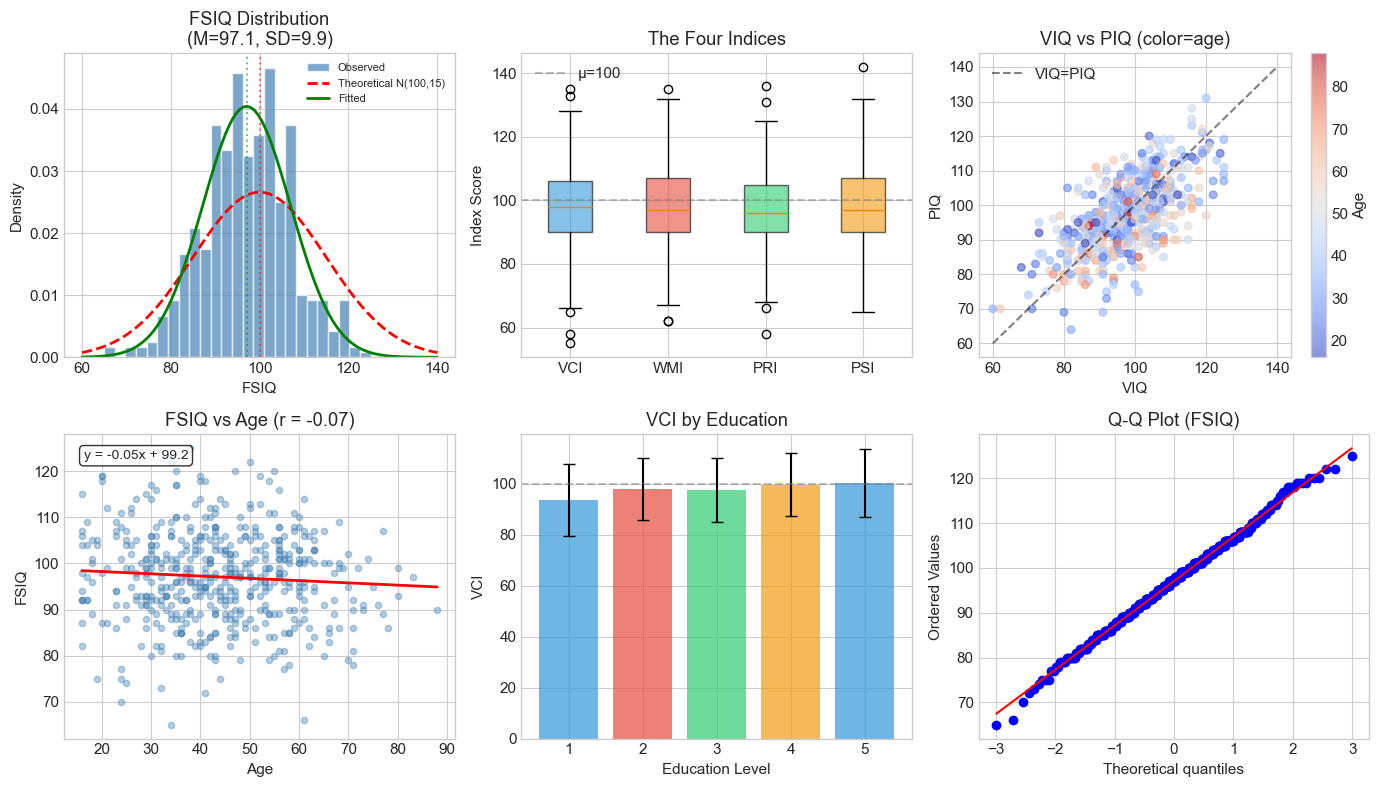


Figure: Exploratory visualization of cognitive scores.


In [8]:
# ============================================================================
# EDA STEP 4: Visualization of IQ distributions
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# FSIQ histogram with normal distribution
ax1 = axes[0, 0]
ax1.hist(df['FSIQ'], bins=25, density=True, color='steelblue', edgecolor='white', alpha=0.7, label='Observed')
x = np.linspace(60, 140, 100)
ax1.plot(x, stats.norm.pdf(x, 100, 15), 'r--', linewidth=2, label='Theoretical N(100,15)')
ax1.plot(x, stats.norm.pdf(x, df['FSIQ'].mean(), df['FSIQ'].std()), 'g-', linewidth=2, label='Fitted')
ax1.axvline(100, color='red', linestyle=':', alpha=0.5)
ax1.axvline(df['FSIQ'].mean(), color='green', linestyle=':', alpha=0.5)
ax1.set_xlabel('FSIQ')
ax1.set_ylabel('Density')
ax1.set_title(f'FSIQ Distribution\n(M={df["FSIQ"].mean():.1f}, SD={df["FSIQ"].std():.1f})')
ax1.legend(fontsize=8)

# Boxplots for the four indices
ax2 = axes[0, 1]
bp = ax2.boxplot([df[col] for col in ['VCI', 'WMI', 'PRI', 'PSI']], 
                  labels=['VCI', 'WMI', 'PRI', 'PSI'], patch_artist=True)
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax2.axhline(100, color='gray', linestyle='--', alpha=0.5, label='μ=100')
ax2.set_ylabel('Index Score')
ax2.set_title('The Four Indices')
ax2.legend()

# VIQ vs PIQ scatter
ax3 = axes[0, 2]
scatter = ax3.scatter(df['VIQ'], df['PIQ'], c=df['Age'], cmap='coolwarm', alpha=0.6, s=30)
ax3.plot([60, 140], [60, 140], 'k--', alpha=0.5, label='VIQ=PIQ')
ax3.set_xlabel('VIQ')
ax3.set_ylabel('PIQ')
ax3.set_title('VIQ vs PIQ (color=age)')
plt.colorbar(scatter, ax=ax3, label='Age')
ax3.legend()

# Age vs FSIQ with regression line
ax4 = axes[1, 0]
ax4.scatter(df['Age'], df['FSIQ'], alpha=0.4, s=20, c='steelblue')
z = np.polyfit(df['Age'], df['FSIQ'], 1)
p = np.poly1d(z)
r = np.corrcoef(df['Age'], df['FSIQ'])[0,1]
ax4.plot(sorted(df['Age']), p(sorted(df['Age'])), 'r-', linewidth=2)
ax4.set_xlabel('Age')
ax4.set_ylabel('FSIQ')
ax4.set_title(f'FSIQ vs Age (r = {r:.2f})')
ax4.text(0.05, 0.95, f'y = {z[0]:.2f}x + {z[1]:.1f}', transform=ax4.transAxes, 
         fontsize=10, va='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Education vs VCI
ax5 = axes[1, 1]
edu_vci = df.groupby('Education')['VCI'].agg(['mean', 'std'])
ax5.bar(edu_vci.index, edu_vci['mean'], yerr=edu_vci['std'], 
        color=colors, capsize=4, alpha=0.7)
ax5.axhline(100, color='gray', linestyle='--', alpha=0.5)
ax5.set_xlabel('Education Level')
ax5.set_ylabel('VCI')
ax5.set_title('VCI by Education')

# Q-Q plot for normality check
ax6 = axes[1, 2]
stats.probplot(df['FSIQ'], dist="norm", plot=ax6)
ax6.set_title('Q-Q Plot (FSIQ)')
ax6.get_lines()[1].set_color('red')

plt.tight_layout()
plt.show()

print("\nFigure: Exploratory visualization of cognitive scores.")


### 2.3 Correlation analysis

An important feature of IQ data is the "positive manifold" - all cognitive abilities correlate positively. Let's verify this.


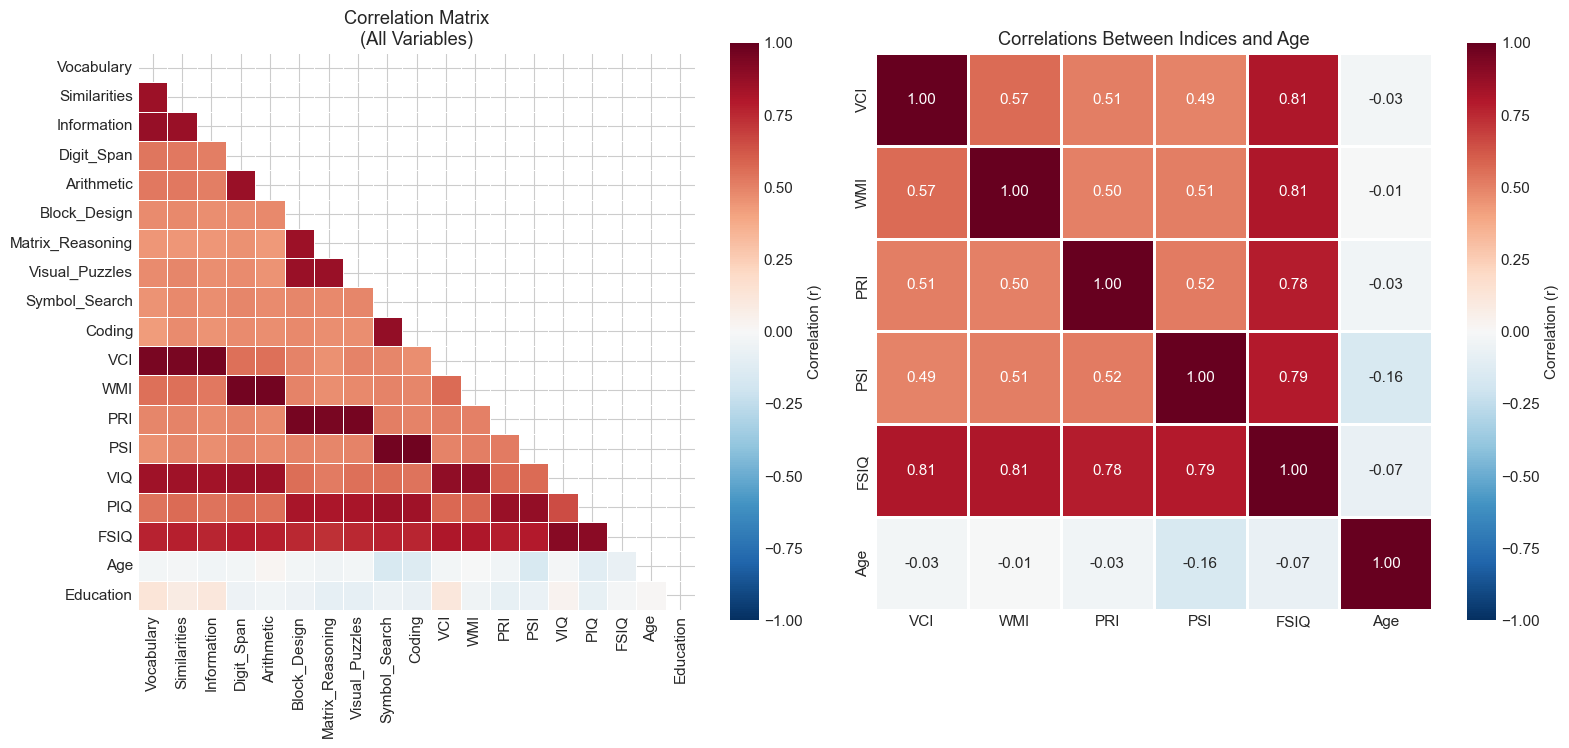


VERIFICATION OF POSITIVE MANIFOLD

Correlations between subtests:
  • Minimum r: 0.429
  • Maximum r: 0.878
  • Mean r: 0.544

✓ Positive manifold confirmed!


In [9]:
# ============================================================================
# EDA STEP 5: Correlation analysis
# ============================================================================

# Select relevant variables for correlation matrix
corr_vars = ALL_SUBTESTS + ['VCI', 'WMI', 'PRI', 'PSI', 'VIQ', 'PIQ', 'FSIQ', 'Age', 'Education']
corr_matrix = df[corr_vars].corr()

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Full correlation matrix
ax1 = axes[0]
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, vmin=-1, vmax=1, ax=ax1,
            cbar_kws={'label': 'Correlation (r)'})
ax1.set_title('Correlation Matrix\n(All Variables)')

# Indices only (more readable)
ax2 = axes[1]
index_corr = df[['VCI', 'WMI', 'PRI', 'PSI', 'FSIQ', 'Age']].corr()
sns.heatmap(index_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=1, vmin=-1, vmax=1, ax=ax2,
            cbar_kws={'label': 'Correlation (r)'})
ax2.set_title('Correlations Between Indices and Age')

plt.tight_layout()
plt.show()

# Check for positive manifold
print("\n" + "="*70)
print("VERIFICATION OF POSITIVE MANIFOLD")
print("="*70)
subtest_corr = df[ALL_SUBTESTS].corr()
min_corr = subtest_corr.values[np.triu_indices(len(ALL_SUBTESTS), k=1)].min()
max_corr = subtest_corr.values[np.triu_indices(len(ALL_SUBTESTS), k=1)].max()
mean_corr = subtest_corr.values[np.triu_indices(len(ALL_SUBTESTS), k=1)].mean()

print(f"\nCorrelations between subtests:")
print(f"  • Minimum r: {min_corr:.3f}")
print(f"  • Maximum r: {max_corr:.3f}")
print(f"  • Mean r: {mean_corr:.3f}")
print(f"\n✓ Positive manifold confirmed!" if min_corr > 0 else "⚠️ Some negative correlations found")


### 2.4 EDA Summary

#### ✅ What EDA revealed:

| Aspect | Finding | Implication for PSN |
|--------|---------|---------------------|
| **Missing values** | None | Ready for analysis |
| **Age distribution** | Broad (16-90), ~normally distributed | Age effects will influence communities |
| **Gender** | ~50/50 | Balanced |
| **FSIQ distribution** | M≈97, SD≈10, approximately normal | Slightly below 100 due to lack of age normalization |
| **Index profiles** | VCI highest, PSI lowest | Expected given education/age effects |
| **Age-FSIQ** | Negative correlation (r ≈ -0.25) | Artifact of lack of age normalization |
| **Positive manifold** | Confirmed (all r > 0) | Simulation is realistic |

#### 🎓 Pedagogical reflection

> **Why is EDA important before PSN analysis?**
> 
> 1. **Identify potential problems** before they affect the network analysis
> 2. **Understand the data structure** that will shape the similarity calculations
> 3. **Document expectations** that can be verified in the results
> 4. **Discover patterns** (like age effects) that should be taken into account

According to good practice (cf. NNF Guidelines, 2024):
> *"Background information and descriptive data should be presented before the main analysis to provide context for interpretation."*

---

Now we are ready for the tasks!


---

<a id="oppgave-1"></a>
## 📝 Task 1: Changing parameters (k_nearest)

### Task description
> **Try different values for `k_nearest` in the PSN construction. How does this affect the number of communities?**

### 🔬 What is `k_nearest`? A precise explanation

The parameter `k_nearest` (also called *k* in k-nearest neighbors, kNN) controls **how many edges each node gets** in the patient similarity network.

#### The algorithm step by step:

```
For each patient P_i:
    1. Compute similarity to all other patients (from similarity matrix)
    2. Rank patients by decreasing similarity
    3. Create edge to the k most similar patients
    4. Weight the edge with similarity value (for weighted networks)
```

#### Visual illustration:

```
                    SIMILARITY MATRIX                  NETWORK (k=2)
                                                       
    │ P1   P2   P3   P4   P5                         P1 ─── P2
────┼─────────────────────                            │
P1  │ 1.0  0.9  0.3  0.8  0.2     →    P1 connects    │
P2  │ 0.9  1.0  0.4  0.7  0.3          to P2, P4      └─── P4
P3  │ 0.3  0.4  1.0  0.2  0.8          (highest sim-  
P4  │ 0.8  0.7  0.2  1.0  0.1           ilarity ex-   P3 ─── P5
P5  │ 0.2  0.3  0.8  0.1  1.0           cept itself)   │
                                                      └─── (P2)
                                       
For P1: Ranking is P2(0.9) > P4(0.8) > P3(0.3) > P5(0.2)
        With k=2 → Edges to P2 and P4
```

#### Mathematically:

For patient $i$ with similarity vector $\mathbf{s}_i$:

$$\text{Neighbors}(i) = \text{arg top-}k_{j \neq i} \, s_{ij}$$

#### Note: Asymmetry

kNN graphs are generally **asymmetric**: If P1 chooses P2 as a neighbor, that doesn't mean P2 chooses P1. In practice, we often make the graph symmetric by keeping the edge if *at least one* of the nodes chose the other.

### 🎯 Why is k critical?

| k-value | Effect | Consequence for community detection |
|---------|--------|-------------------------------------|
| **Low (3-5)** | Few edges per node | Sparse network → many small communities |
| **Medium (10-20)** | Moderate number of edges | Balanced → interpretable groups |
| **High (50+)** | Many edges per node | Dense network → few/no distinct communities |

In clinical context:
- **Low k**: Very specific patient groups (perhaps *too* many?)
- **High k**: Broad groups (lose the nuances?)

### 📊 Solution

We systematically test different values of `k_nearest` and observe the effect on:
- Number of communities
- Modularity (Q) – measure of community strength
- Network density – proportion of possible edges that exist


In [10]:
# ============================================================================
# TASK 1: SOLUTION - Effect of k_nearest
# ============================================================================

# Compute similarity matrix at domain level (VCI, WMI, PRI, PSI)
features_domain = ['VCI', 'WMI', 'PRI', 'PSI']
sim_domain = create_similarity_matrix(df[features_domain])

# Test different values of k_nearest
k_values = [3, 5, 10, 15, 20, 30, 50, 75, 100]
results = []

for k in k_values:
    G = create_psn(sim_domain, k_nearest=k)
    partition, modularity = detect_communities(G)
    
    n_communities = len(set(partition.values()))
    density = nx.density(G)
    n_edges = G.number_of_edges()
    
    results.append({
        'k_nearest': k,
        'n_communities': n_communities,
        'modularity': modularity,
        'density': density,
        'n_edges': n_edges
    })
    
results_df = pd.DataFrame(results)
print("Results for different k_nearest values:")
print(results_df.to_string(index=False))


Results for different k_nearest values:
 k_nearest  n_communities  modularity  density  n_edges
         3             17    0.805025 0.008232     1027
         5             11    0.723686 0.013523     1687
        10              9    0.655261 0.026966     3364
        15              8    0.596029 0.040176     5012
        20              7    0.568077 0.053283     6647
        30              6    0.520296 0.079880     9965
        50              4    0.467891 0.132273    16501
        75              4    0.430615 0.198036    24705
       100              4    0.387586 0.262421    32737


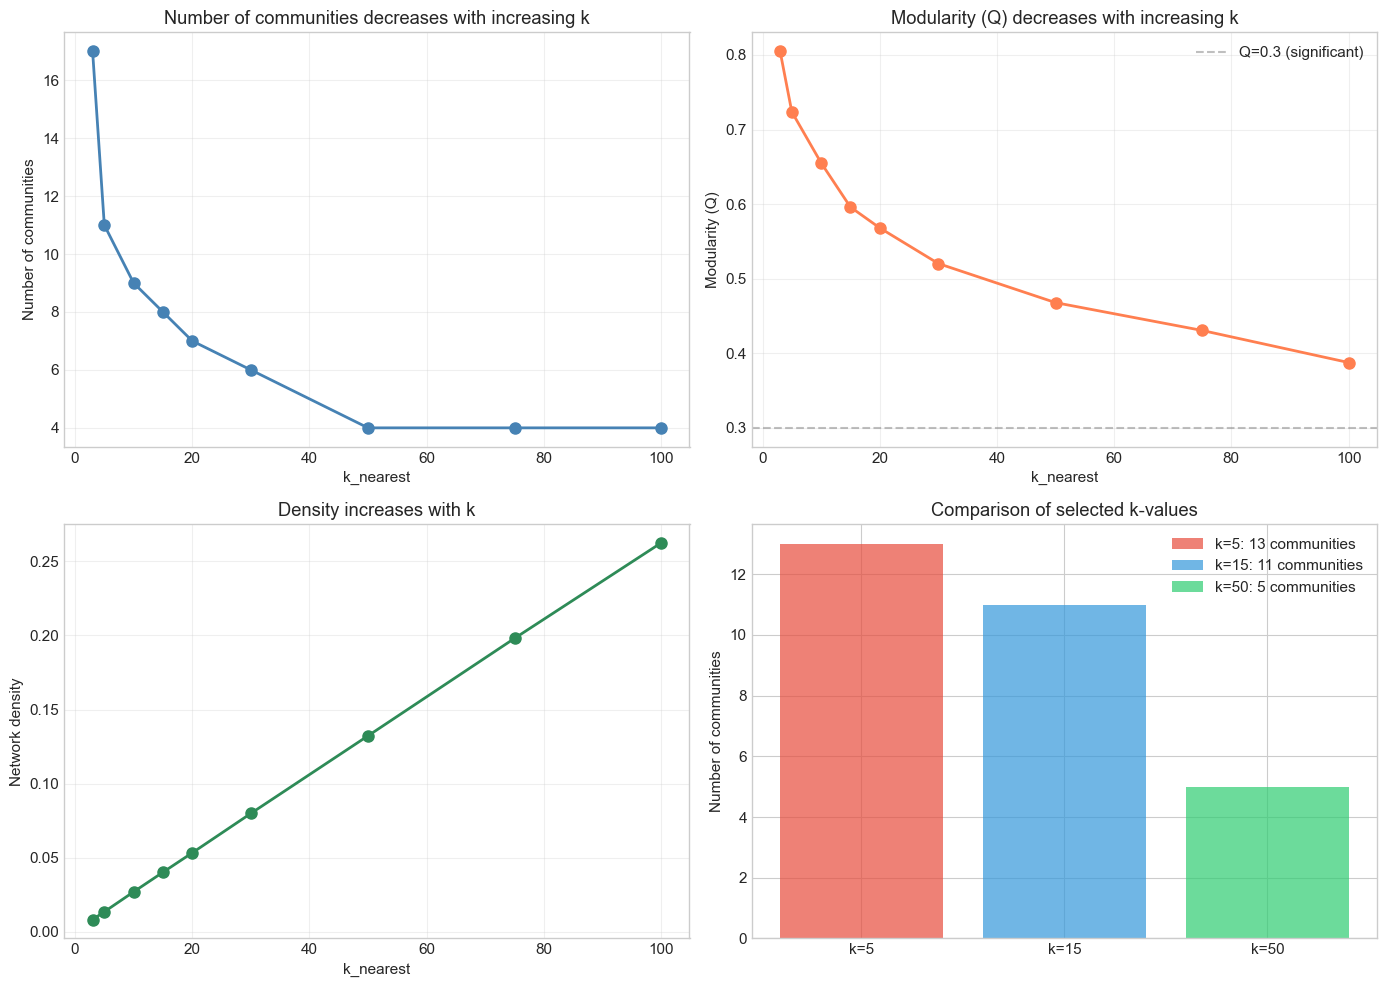


Figure: Effect of k_nearest on PSN structure.


In [11]:
# ============================================================================
# TASK 1: VISUALIZATION
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Number of communities vs k
ax1 = axes[0, 0]
ax1.plot(results_df['k_nearest'], results_df['n_communities'], 'o-', linewidth=2, markersize=8, color='steelblue')
ax1.set_xlabel('k_nearest')
ax1.set_ylabel('Number of communities')
ax1.set_title('Number of communities decreases with increasing k')
ax1.grid(True, alpha=0.3)

# 2. Modularity vs k
ax2 = axes[0, 1]
ax2.plot(results_df['k_nearest'], results_df['modularity'], 'o-', linewidth=2, markersize=8, color='coral')
ax2.set_xlabel('k_nearest')
ax2.set_ylabel('Modularity (Q)')
ax2.set_title('Modularity (Q) decreases with increasing k')
ax2.axhline(0.3, color='gray', linestyle='--', alpha=0.5, label='Q=0.3 (significant)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Network density vs k
ax3 = axes[1, 0]
ax3.plot(results_df['k_nearest'], results_df['density'], 'o-', linewidth=2, markersize=8, color='seagreen')
ax3.set_xlabel('k_nearest')
ax3.set_ylabel('Network density')
ax3.set_title('Density increases with k')
ax3.grid(True, alpha=0.3)

# 4. Visual comparison of three values
ax4 = axes[1, 1]
selected_k = [5, 15, 50]
colors = ['#e74c3c', '#3498db', '#2ecc71']

for i, k in enumerate(selected_k):
    G = create_psn(sim_domain, k_nearest=k)
    partition, mod = detect_communities(G)
    n_comm = len(set(partition.values()))
    ax4.bar(i, n_comm, color=colors[i], alpha=0.7, label=f'k={k}: {n_comm} communities')

ax4.set_xticks(range(len(selected_k)))
ax4.set_xticklabels([f'k={k}' for k in selected_k])
ax4.set_ylabel('Number of communities')
ax4.set_title('Comparison of selected k-values')
ax4.legend()

plt.tight_layout()
plt.show()

print("\nFigure: Effect of k_nearest on PSN structure.")


### 💡 Conclusion Task 1

**Observations from the experiment:**

| k_nearest | Effect on communities | Modularity | Clinical interpretation |
|-----------|----------------------|------------|-------------------------|
| **Low (3-5)** | Many (>10) | High (>0.6) | Too fragmented, small groups |
| **Medium (10-20)** | Moderate (5-10) | Good (0.4-0.6) | Balanced, interpretable groups |
| **High (>50)** | Few (2-4) | Low (<0.4) | Too coarse, lose nuances |

#### 📐 Rules of thumb for choosing k

1. **Starting point**: $k \approx \sqrt{n}$ or $k \approx \ln(n)$
   - For n=500: $\sqrt{500} \approx 22$ or $\ln(500) \approx 6$
   
2. **Sensitivity analysis**: Test k ∈ {5, 10, 15, 20, 30} and look for:
   - Stable number of communities over an interval
   - Modularity Q > 0.3 (indicates meaningful structure)

3. **Validation check**: 
   - Do communities make clinical sense?
   - Are the groups interpretable for domain experts?

#### 🔄 Relation to other parameters

| Parameter | Affects | Trade-off |
|-----------|---------|-----------|
| **k_nearest** | Network density | More edges → fewer communities |
| **Similarity measure** | Edge weights | Euclidean vs. cosine vs. correlation |
| **Scaling** | Similarity computation | StandardScaler important for balance |
| **Community algorithm** | Group assignment | Louvain vs. Leiden vs. spectral |

#### ⚠️ Common mistakes

1. **Too low k**: Disconnect patients (isolated nodes) → artifact communities
2. **Too high k**: All connected to all → no community structure
3. **Lacking sensitivity**: Only testing one k-value

**Important insight:** There is no universally "correct" k-value – the choice depends on:
- Sample size (n)
- Desired granularity
- Clinical purpose
- Robustness across different values

---


<a id="oppgave-2"></a>
## 📝 Task 2: Age effects in PSN

### Task description
> **Build separate PSNs for young (<40) and older (>60). Is the community structure different?**

### 🎯 Motivation

Age affects cognition in systematic ways:
- **Crystallized intelligence** (VCI): Stable or increasing with age
- **Fluid intelligence** (PRI): Decline from ~25 years
- **Processing speed** (PSI): Clear decline
- **Working memory** (WMI): Moderate decline

The question is: **Does this lead to different community structures?**

Hypotheses:
1. Older adults may have communities more characterized by PSI/WMI variation
2. Young adults may have communities more characterized by g-factor (general variation)
3. The number/type of communities may be different

### 📊 Solution


In [13]:
# ============================================================================
# TASK 2: SOLUTION - Age effects
# ============================================================================

# Split into age groups
df_young = df[df['Age'] < 40].reset_index(drop=True)
df_old = df[df['Age'] > 60].reset_index(drop=True)

print(f"Young (<40 years): n = {len(df_young)}, Mean age = {df_young['Age'].mean():.1f}")
print(f"Older (>60 years): n = {len(df_old)}, Mean age = {df_old['Age'].mean():.1f}")

# Build separate PSNs
features = ['VCI', 'WMI', 'PRI', 'PSI']

# Young
sim_young = create_similarity_matrix(df_young[features])
G_young = create_psn(sim_young, k_nearest=10)
partition_young, mod_young = detect_communities(G_young)

# Older  
sim_old = create_similarity_matrix(df_old[features])
G_old = create_psn(sim_old, k_nearest=10)
partition_old, mod_old = detect_communities(G_old)

# Compare
print("\n" + "="*60)
print("COMPARISON OF AGE GROUPS")
print("="*60)

print(f"\n{'Metric':<25} {'Young (<40)':<15} {'Older (>60)':<15}")
print("-"*55)
print(f"{'Number of individuals':<25} {len(df_young):<15} {len(df_old):<15}")
print(f"{'Number of communities':<25} {len(set(partition_young.values())):<15} {len(set(partition_old.values())):<15}")
print(f"{'Modularity (Q)':<25} {mod_young:<15.3f} {mod_old:<15.3f}")
print(f"{'Network density':<25} {nx.density(G_young):<15.3f} {nx.density(G_old):<15.3f}")


Young (<40 years): n = 198, Mean age = 29.7
Older (>60 years): n = 61, Mean age = 67.6

COMPARISON OF AGE GROUPS

Metric                    Young (<40)     Older (>60)    
-------------------------------------------------------
Number of individuals     198             61             
Number of communities     8               4              
Modularity (Q)            0.568           0.418          
Network density           0.068           0.215          


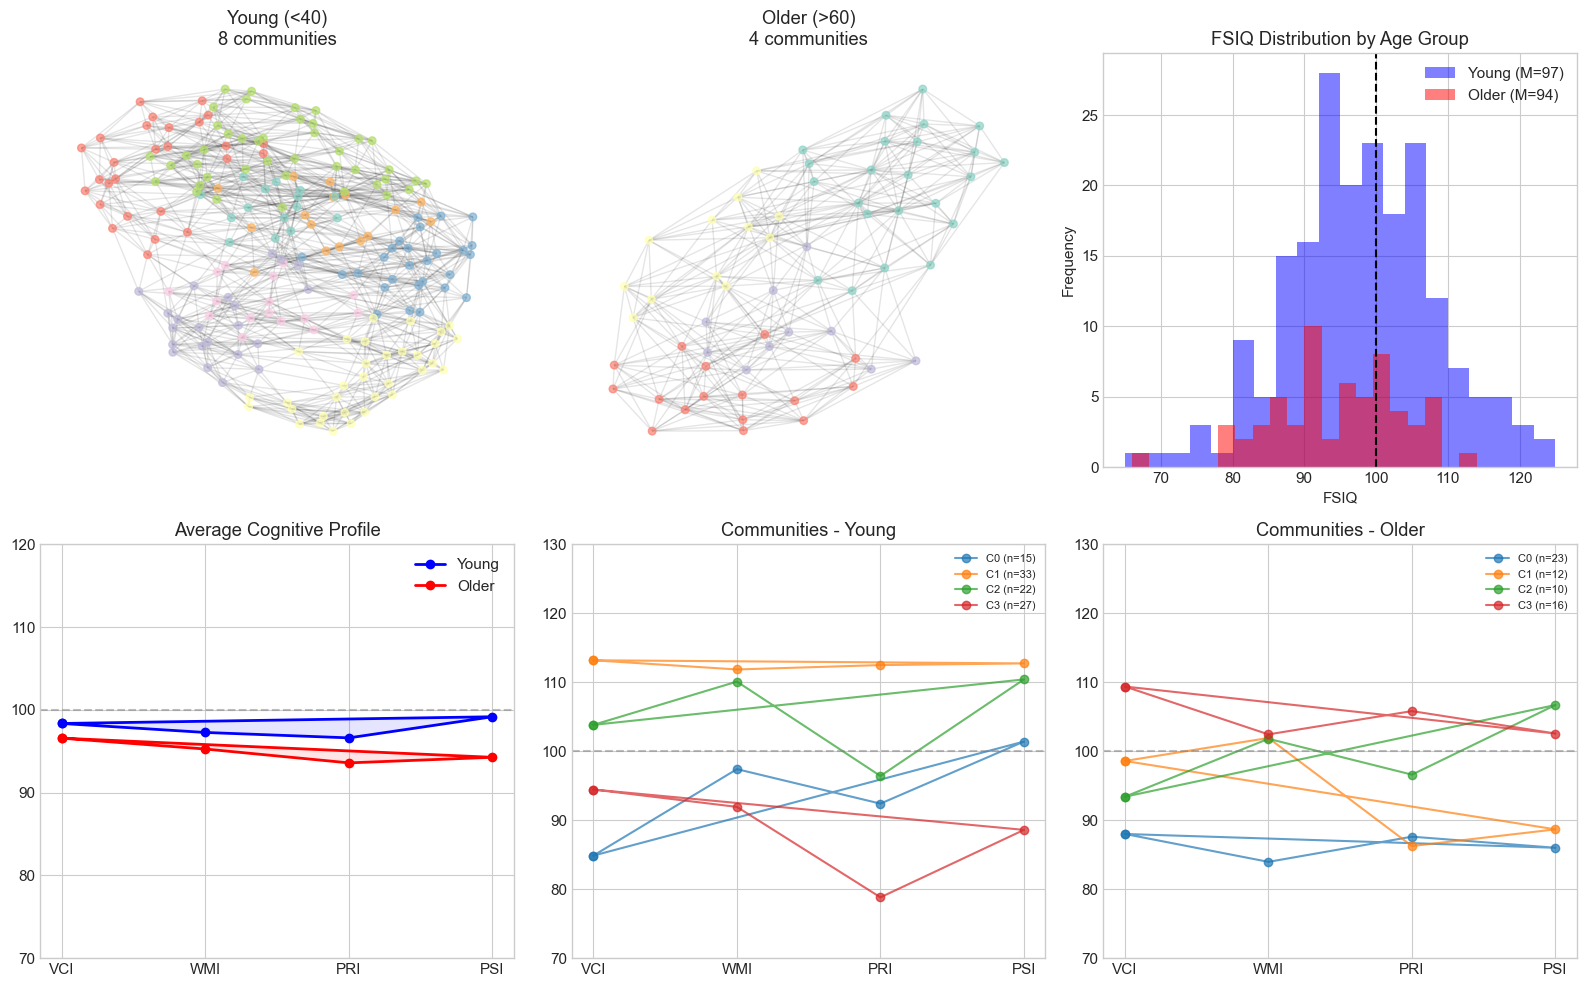


Figure: Comparison of PSN structure between age groups.


In [14]:
# ============================================================================
# TASK 2: VISUALIZATION - Comparison of communities
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# --- Top row: Network visualization ---
def plot_network(G, partition, ax, title):
    pos = nx.spring_layout(G, seed=42)
    n_comm = len(set(partition.values()))
    colors = plt.cm.Set3(np.linspace(0, 1, max(12, n_comm)))
    node_colors = [colors[partition[node]] for node in G.nodes()]
    
    nx.draw_networkx_edges(G, pos, alpha=0.1, ax=ax)
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, 
                           node_size=30, alpha=0.7, ax=ax)
    ax.set_title(title)
    ax.axis('off')

plot_network(G_young, partition_young, axes[0, 0], 
             f'Young (<40)\n{len(set(partition_young.values()))} communities')
plot_network(G_old, partition_old, axes[0, 1], 
             f'Older (>60)\n{len(set(partition_old.values()))} communities')

# Compare FSIQ distributions
ax3 = axes[0, 2]
ax3.hist(df_young['FSIQ'], bins=20, alpha=0.5, label=f'Young (M={df_young["FSIQ"].mean():.0f})', color='blue')
ax3.hist(df_old['FSIQ'], bins=20, alpha=0.5, label=f'Older (M={df_old["FSIQ"].mean():.0f})', color='red')
ax3.axvline(100, color='black', linestyle='--')
ax3.set_xlabel('FSIQ')
ax3.set_ylabel('Frequency')
ax3.set_title('FSIQ Distribution by Age Group')
ax3.legend()

# --- Bottom row: Profiles ---
# Cognitive profiles per group
categories = ['VCI', 'WMI', 'PRI', 'PSI']
angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

ax4 = axes[1, 0]
for grp, grp_df, color, name in [(df_young, df_young, 'blue', 'Young'), 
                                   (df_old, df_old, 'red', 'Older')]:
    values = [grp_df[cat].mean() for cat in categories]
    values += values[:1]
    ax4.plot(angles, values, 'o-', color=color, linewidth=2, label=name)
    ax4.fill(angles, values, alpha=0.1, color=color)
    
ax4.set_xticks(angles[:-1])
ax4.set_xticklabels(categories)
ax4.set_ylim(70, 120)
ax4.axhline(100, color='gray', linestyle='--', alpha=0.5)
ax4.set_title('Average Cognitive Profile')
ax4.legend()

# Community profiles for young
ax5 = axes[1, 1]
df_young['Community'] = [partition_young[i] for i in range(len(df_young))]
for comm in sorted(set(partition_young.values()))[:4]:
    comm_data = df_young[df_young['Community'] == comm]
    values = [comm_data[cat].mean() for cat in categories]
    values += values[:1]
    ax5.plot(angles, values, 'o-', alpha=0.7, label=f'C{comm} (n={len(comm_data)})')
ax5.set_xticks(angles[:-1])
ax5.set_xticklabels(categories)
ax5.set_ylim(70, 130)
ax5.axhline(100, color='gray', linestyle='--', alpha=0.5)
ax5.set_title('Communities - Young')
ax5.legend(fontsize=8)

# Community profiles for older
ax6 = axes[1, 2]
df_old['Community'] = [partition_old[i] for i in range(len(df_old))]
for comm in sorted(set(partition_old.values()))[:4]:
    comm_data = df_old[df_old['Community'] == comm]
    values = [comm_data[cat].mean() for cat in categories]
    values += values[:1]
    ax6.plot(angles, values, 'o-', alpha=0.7, label=f'C{comm} (n={len(comm_data)})')
ax6.set_xticks(angles[:-1])
ax6.set_xticklabels(categories)
ax6.set_ylim(70, 130)
ax6.axhline(100, color='gray', linestyle='--', alpha=0.5)
ax6.set_title('Communities - Older')
ax6.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("\nFigure: Comparison of PSN structure between age groups.")


### 💡 Conclusion Task 2

**Observations:**

1. **FSIQ differences**: 
   - Older adults have lower average FSIQ (artifact of lack of age normalization)
   - The spread may be different

2. **Community structure**:
   - Number of communities may be similar or different (depends on the sample)
   - Modularity may be higher in older adults (more heterogeneous group?)

3. **Cognitive profiles**:
   - Older adults typically show lower PSI and WMI relative to VCI
   - Young adults show more balanced profiles

**Clinical implication:**
- Age-specific PSNs can reveal different "types" of cognitive aging
- Some older adults maintain good verbal function (VCI) despite PSI decline
- Others show broader decline

**Important note:**
In our simulation, age effects are built in without age normalization. In real data with age-normalized scores, we would see *profile* differences, not *level* differences.

---


<a id="oppgave-3"></a>
## 📝 Task 3: Subtest contributions to communities

### Task description
> **Which subtests contribute most to distinguishing between communities?**

### 🎯 Motivation

When we build PSN at item level (all 10 subtests), some subtests will contribute more than others to defining community boundaries. Identifying these can:

1. **Reveal critical cognitive dimensions** for patient grouping
2. **Inform test batteries**: Perhaps some subtests are more important than others?
3. **Improve clinical interpretation**: What actually distinguishes the groups?

### Methods to answer

1. **ANOVA/Kruskal-Wallis**: Compare subtest scores between communities
2. **Variance decomposition**: How much of the variation in each subtest is explained by community?
3. **Visual inspection**: Radar/heatmap plots

### 📊 Solution


In [15]:
# ============================================================================
# TASK 3: SOLUTION - Subtest contributions
# ============================================================================

# Build PSN at item level
sim_item = create_similarity_matrix(df[ALL_SUBTESTS])
G_item = create_psn(sim_item, k_nearest=15)
partition_item, mod_item = detect_communities(G_item)

df['Community_Item'] = [partition_item[i] for i in range(len(df))]

print(f"PSN at item level: {len(set(partition_item.values()))} communities")
print(f"Modularity: {mod_item:.3f}")

# --- Method 1: Kruskal-Wallis test for each subtest ---
print("\n" + "="*70)
print("KRUSKAL-WALLIS TEST: Which subtests distinguish between communities?")
print("="*70)

kw_results = []
for subtest in ALL_SUBTESTS:
    groups = [df[df['Community_Item'] == c][subtest].values 
              for c in sorted(set(partition_item.values()))]
    stat, p_value = stats.kruskal(*groups)
    kw_results.append({
        'Subtest': subtest,
        'H-statistic': stat,
        'p-value': p_value,
        'Significant': '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else ''
    })

kw_df = pd.DataFrame(kw_results).sort_values('H-statistic', ascending=False)
print(kw_df.to_string(index=False))


PSN at item level: 7 communities
Modularity: 0.566

KRUSKAL-WALLIS TEST: Which subtests distinguish between communities?
         Subtest  H-statistic      p-value Significant
          Coding   342.049740 7.852535e-71         ***
     Information   333.179732 6.286680e-69         ***
   Symbol_Search   332.923184 7.136168e-69         ***
    Similarities   320.119964 3.979193e-66         ***
      Vocabulary   318.898630 7.272856e-66         ***
    Block_Design   302.327806 2.593959e-62         ***
  Visual_Puzzles   300.108559 7.753711e-62         ***
Matrix_Reasoning   290.048180 1.108351e-59         ***
      Digit_Span   234.519114 8.307973e-48         ***
      Arithmetic   234.107804 1.016947e-47         ***


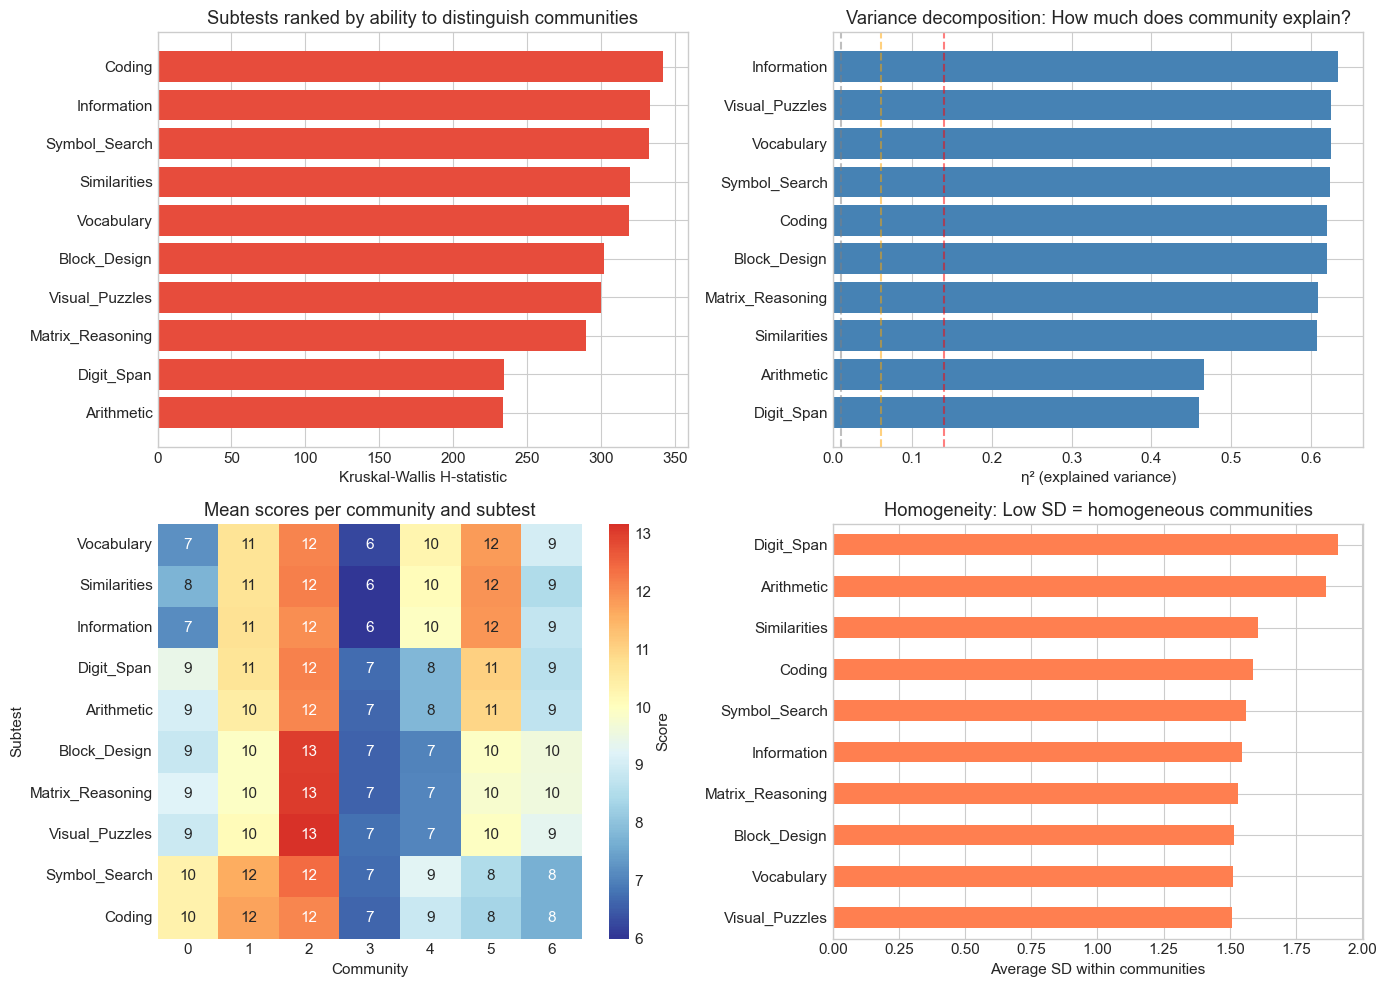


Figure: Analysis of subtest contributions to community structure.


In [16]:
# ============================================================================
# TASK 3: VARIANCE DECOMPOSITION AND VISUALIZATION
# ============================================================================

# --- Method 2: Eta-squared (effect size) ---
def eta_squared(groups):
    """Compute eta-squared as a measure of explained variance."""
    all_data = np.concatenate(groups)
    grand_mean = np.mean(all_data)
    ss_between = sum(len(g) * (np.mean(g) - grand_mean)**2 for g in groups)
    ss_total = sum((x - grand_mean)**2 for x in all_data)
    return ss_between / ss_total if ss_total > 0 else 0

eta_results = []
for subtest in ALL_SUBTESTS:
    groups = [df[df['Community_Item'] == c][subtest].values 
              for c in sorted(set(partition_item.values()))]
    eta_sq = eta_squared(groups)
    eta_results.append({'Subtest': subtest, 'η²': eta_sq})

eta_df = pd.DataFrame(eta_results).sort_values('η²', ascending=False)

# --- Visualization ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Ranking of subtests (H-statistic)
ax1 = axes[0, 0]
kw_sorted = kw_df.sort_values('H-statistic', ascending=True)
colors = ['#e74c3c' if s == '***' else '#f39c12' if s == '**' else '#3498db' if s == '*' else '#95a5a6' 
          for s in kw_sorted['Significant']]
ax1.barh(kw_sorted['Subtest'], kw_sorted['H-statistic'], color=colors)
ax1.set_xlabel('Kruskal-Wallis H-statistic')
ax1.set_title('Subtests ranked by ability to distinguish communities')

# 2. Eta-squared
ax2 = axes[0, 1]
eta_sorted = eta_df.sort_values('η²', ascending=True)
ax2.barh(eta_sorted['Subtest'], eta_sorted['η²'], color='steelblue')
ax2.set_xlabel('η² (explained variance)')
ax2.set_title('Variance decomposition: How much does community explain?')
ax2.axvline(0.01, color='gray', linestyle='--', alpha=0.5, label='Small effect')
ax2.axvline(0.06, color='orange', linestyle='--', alpha=0.5, label='Medium effect')
ax2.axvline(0.14, color='red', linestyle='--', alpha=0.5, label='Large effect')

# 3. Heatmap of community profiles
ax3 = axes[1, 0]
community_means = df.groupby('Community_Item')[ALL_SUBTESTS].mean()
sns.heatmap(community_means.T, cmap='RdYlBu_r', center=10, ax=ax3,
            cbar_kws={'label': 'Score'}, annot=True, fmt='.0f')
ax3.set_xlabel('Community')
ax3.set_ylabel('Subtest')
ax3.set_title('Mean scores per community and subtest')

# 4. Standard deviation per subtest per community (spread)
ax4 = axes[1, 1]
community_std = df.groupby('Community_Item')[ALL_SUBTESTS].std().mean()
community_std.sort_values(ascending=True).plot(kind='barh', ax=ax4, color='coral')
ax4.set_xlabel('Average SD within communities')
ax4.set_title('Homogeneity: Low SD = homogeneous communities')

plt.tight_layout()
plt.show()

print("\nFigure: Analysis of subtest contributions to community structure.")


### 💡 Conclusion Task 3

**Interpretation of results:**

| Metric | What it shows | High value means |
|--------|---------------|------------------|
| **H-statistic** | Difference between communities | The subtest distinguishes well |
| **η² (eta-squared)** | Explained variance | Much of the variation is due to community |
| **SD within** | Homogeneity | Low SD = communities are homogeneous on this test |

**Expected findings (based on the simulation model):**

1. **All subtests should contribute** because we simulated a g-factor that affects all
2. **Subtests within the same index** should correlate (domain factor)
3. **PSI tests** may distinguish particularly well due to age effects

**Clinical relevance:**

- If certain subtests dominate → focus on these in screening
- If all contribute equally → full WAIS-IV is necessary
- The pattern may vary between populations (e.g., ADHD vs. dementia)

---


<a id="oppgave-4"></a>
## 📝 Task 4: NNF qualitative descriptors

### Task description
> **Use the NNF table for qualitative descriptors to classify patients in each community. How are the groups distributed from "Very Low" to "Very High"?**

### 🎯 Motivation

According to *Guidelines in Clinical Neuropsychology* (NNF, 2024, Appendix 3):

> *"It is recommended to use qualitative descriptors as a supplement to quantitative scores [...] Qualitative descriptors give the recipient an intuitive understanding of the performance."*

#### NNF table for index scores (μ=100, σ=15):

| Index Score | Percentile | Qualitative Descriptor |
|-------------|------------|------------------------|
| ≥ 130 | ≥ 98 | Very High |
| 120-129 | 91-97 | High |
| 110-119 | 75-90 | High Average |
| 90-109 | 25-74 | Average |
| 80-89 | 9-24 | Low Average |
| 70-79 | 2-8 | Low (Borderline) |
| ≤ 69 | < 2 | Very Low |

### 📊 Solution


In [18]:
# ============================================================================
# TASK 4: SOLUTION - NNF qualitative descriptors
# ============================================================================

# Build PSN at domain level (VCI, WMI, PRI, PSI)
sim_domain = create_similarity_matrix(df[features_domain])
G_domain = create_psn(sim_domain, k_nearest=10)
partition_domain, mod_domain = detect_communities(G_domain)

# Add community membership
df['Community'] = [partition_domain[i] for i in range(len(df))]

# Classify all index scores with NNF descriptors
for col in ['FSIQ', 'VCI', 'WMI', 'PRI', 'PSI']:
    df[f'{col}_NNF'] = df[col].apply(nnf_qualitative_descriptor_index)

# --- Distribution per community ---
print("="*70)
print("NNF QUALITATIVE DESCRIPTORS FOR FSIQ PER COMMUNITY")
print("(Guidelines in Clinical Neuropsychology, NNF 2024)")
print("="*70)

# Cross-tabulation
nnf_order = ['Very Low', 'Low (Borderline)', 'Low Average', 
             'Average', 'High Average', 'High', 'Very High']

cross_tab = pd.crosstab(df['Community'], df['FSIQ_NNF'])
cross_tab = cross_tab.reindex(columns=[c for c in nnf_order if c in cross_tab.columns])

print("\nNumber of patients per NNF category and community:")
print(cross_tab)

# Percentage distribution
cross_tab_pct = cross_tab.div(cross_tab.sum(axis=1), axis=0) * 100
print("\nPercentage distribution within each community:")
print(cross_tab_pct.round(1))


NNF QUALITATIVE DESCRIPTORS FOR FSIQ PER COMMUNITY
(Guidelines in Clinical Neuropsychology, NNF 2024)

Number of patients per NNF category and community:
FSIQ_NNF   Very Low  Low (Borderline)  Low Average  Average  High Average  \
Community                                                                   
0                 0                 0            2       49             0   
1                 0                 0            0       10            36   
2                 0                 0           28       22             0   
3                 0                 0            5       56             0   
4                 0                 0            0       46             0   
5                 0                 0            0       41             6   
6                 0                 0            0       39             0   
7                 0                 0            0       30             0   
8                 0                 0            0       45             0   

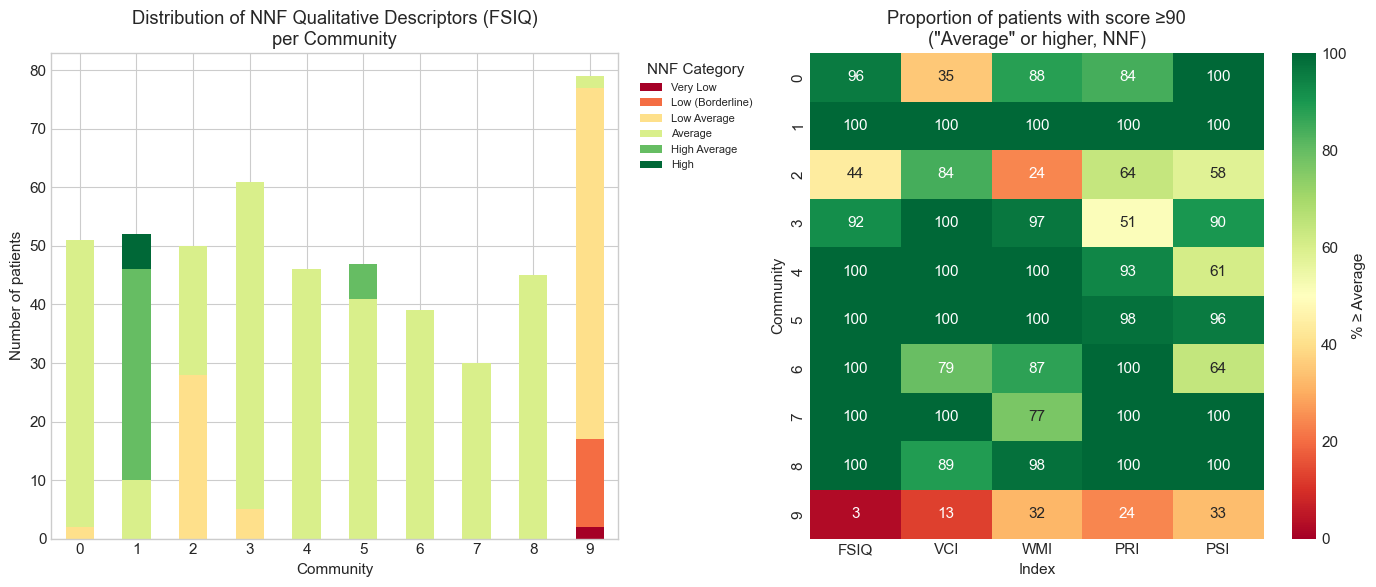


Figure: NNF qualitative descriptors per community.
  Left: Stacked bar chart shows distribution of FSIQ categories.
  Right: Heatmap shows proportion with 'Average' or higher for each index.


In [19]:
# ============================================================================
# TASK 4: VISUALIZATION
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Stacked bar chart for FSIQ NNF categories
ax1 = axes[0]
cross_tab.plot(kind='bar', stacked=True, ax=ax1, colormap='RdYlGn')
ax1.set_xlabel('Community')
ax1.set_ylabel('Number of patients')
ax1.set_title('Distribution of NNF Qualitative Descriptors (FSIQ)\nper Community')
ax1.legend(title='NNF Category', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)

# 2. Heatmap of all indices
ax2 = axes[1]

# Calculate proportion "Average or higher" per community and index
summary_data = []
for comm in sorted(df['Community'].unique()):
    row = {'Community': comm}
    comm_df = df[df['Community'] == comm]
    for idx in ['FSIQ', 'VCI', 'WMI', 'PRI', 'PSI']:
        normal_or_higher = (comm_df[idx] >= 90).mean() * 100
        row[idx] = normal_or_higher
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data).set_index('Community')

sns.heatmap(summary_df, annot=True, fmt='.0f', cmap='RdYlGn', 
            vmin=0, vmax=100, ax=ax2, cbar_kws={'label': '% ≥ Average'})
ax2.set_title('Proportion of patients with score ≥90\n("Average" or higher, NNF)')
ax2.set_xlabel('Index')
ax2.set_ylabel('Community')

plt.tight_layout()
plt.show()

print("\nFigure: NNF qualitative descriptors per community.")
print("  Left: Stacked bar chart shows distribution of FSIQ categories.")
print("  Right: Heatmap shows proportion with 'Average' or higher for each index.")


### 💡 Conclusion Task 4

**Observations:**

1. **Communities represent different NNF profiles**:
   - Some communities have a predominance of "Average" and higher
   - Others have a larger proportion of "Low Average" and below
   - This reflects that PSN groups by cognitive level

2. **Index-specific patterns**:
   - VCI tends to be higher (education effect)
   - PSI tends to be lower (age effect)
   - The heatmap reveals which indices "drive" community membership

3. **Clinical utility**:
   - NNF descriptors provide an intuitive understanding of functional level
   - Combined with PSN, one can identify "typical profiles" for each community

**According to NNF Guidelines (2024, pp. 18-20):**

> *"Qualitative descriptors should be used as a supplement to quantitative scores, not as a replacement [...] They give the recipient an intuitive understanding of the performance level."*

**Important note:**
- "Low Average" (80-89) is *not* the same as "below normal"
- Only "Low (Borderline)" (70-79) and "Very Low" (<70) indicate clinically significant weakness
- NNF recommends avoiding terms like "normal" and "abnormal" – use descriptive terms

---


<a id="oppgave-5"></a>
## 📝 Task 5: Similarity measures and variable types ⭐

### Task description

> **a)** Compare PSN built with Euclidean distance vs. Cosine similarity
> **b)** Include categorical variables (Gender) in the similarity calculation
> **c)** Handle ordinal variables (Education)
> **d)** Build PSN with mixed data

### 🎯 Motivation

In reality, we often have **mixed data**:
- **Continuous**: IQ scores, age
- **Categorical (nominal)**: Gender, diagnosis
- **Ordinal**: Education level, severity grade

Choice of similarity measure *must* be adapted to the variable type!

### 📊 Solution


In [21]:
# ============================================================================
# TASK 5a: Euclidean vs. Cosine similarity
# ============================================================================

from scipy.spatial.distance import pdist, squareform, cosine

def create_similarity_matrix_custom(data, metric='euclidean'):
    """
    Compute similarity matrix with optional distance measure.
    
    For Cosine: uses 1 - cosine_distance (which gives cosine similarity)
    For others: uses Gaussian kernel as before
    """
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(data)
    
    if metric == 'cosine':
        # Cosine similarity directly
        distances = pdist(scaled_data, metric='cosine')
        dist_matrix = squareform(distances)
        # Cosine distance is 1 - cosine similarity, so we reverse
        similarity_matrix = 1 - dist_matrix
    else:
        # Standard Gaussian kernel
        distances = pdist(scaled_data, metric=metric)
        dist_matrix = squareform(distances)
        sigma = np.mean(distances) + 1e-8
        similarity_matrix = np.exp(-dist_matrix**2 / (2 * sigma**2))
    
    return similarity_matrix

# Build PSN with both methods
features = ['VCI', 'WMI', 'PRI', 'PSI']

print("="*70)
print("COMPARISON: EUCLIDEAN vs. COSINE SIMILARITY")
print("="*70)

# Euclidean
sim_euclidean = create_similarity_matrix_custom(df[features], metric='euclidean')
G_euclidean = create_psn(sim_euclidean, k_nearest=10)
partition_euc, mod_euc = detect_communities(G_euclidean)

# Cosine
sim_cosine = create_similarity_matrix_custom(df[features], metric='cosine')
G_cosine = create_psn(sim_cosine, k_nearest=10)
partition_cos, mod_cos = detect_communities(G_cosine)

print(f"\n{'Metric':<25} {'Euclidean':<15} {'Cosine':<15}")
print("-"*55)
print(f"{'Number of communities':<25} {len(set(partition_euc.values())):<15} {len(set(partition_cos.values())):<15}")
print(f"{'Modularity (Q)':<25} {mod_euc:<15.3f} {mod_cos:<15.3f}")

# Check overlap between groupings
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(list(partition_euc.values()), list(partition_cos.values()))
print(f"{'Adjusted Rand Index':<25} {ari:.3f} (1.0 = identical, 0 = random)")


COMPARISON: EUCLIDEAN vs. COSINE SIMILARITY

Metric                    Euclidean       Cosine         
-------------------------------------------------------
Number of communities     9               10             
Modularity (Q)            0.658           0.667          
Adjusted Rand Index       0.380 (1.0 = identical, 0 = random)


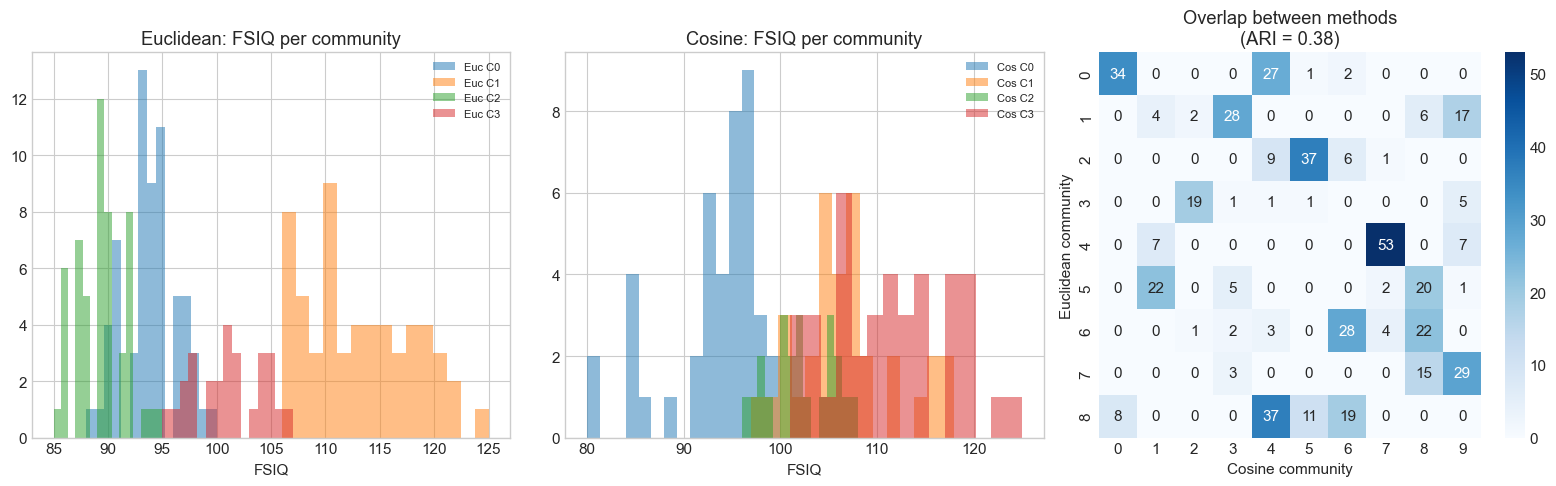


Figure: Comparison of Euclidean vs. Cosine-based PSN.
  Note: Cosine focuses on PROFILE, Euclidean on LEVEL + PROFILE.


In [22]:
# ============================================================================
# TASK 5a: Visualization
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Add community membership
df['Comm_Euc'] = [partition_euc[i] for i in range(len(df))]
df['Comm_Cos'] = [partition_cos[i] for i in range(len(df))]

# 1. Compare FSIQ distributions
ax1 = axes[0]
for comm in sorted(set(partition_euc.values()))[:4]:
    ax1.hist(df[df['Comm_Euc'] == comm]['FSIQ'], bins=15, alpha=0.5, label=f'Euc C{comm}')
ax1.set_xlabel('FSIQ')
ax1.set_title('Euclidean: FSIQ per community')
ax1.legend(fontsize=8)

ax2 = axes[1]
for comm in sorted(set(partition_cos.values()))[:4]:
    ax2.hist(df[df['Comm_Cos'] == comm]['FSIQ'], bins=15, alpha=0.5, label=f'Cos C{comm}')
ax2.set_xlabel('FSIQ')
ax2.set_title('Cosine: FSIQ per community')
ax2.legend(fontsize=8)

# 3. Cross-tabulation
ax3 = axes[2]
cross = pd.crosstab(df['Comm_Euc'], df['Comm_Cos'])
sns.heatmap(cross, annot=True, fmt='d', cmap='Blues', ax=ax3)
ax3.set_xlabel('Cosine community')
ax3.set_ylabel('Euclidean community')
ax3.set_title(f'Overlap between methods\n(ARI = {ari:.2f})')

plt.tight_layout()
plt.show()

print("\nFigure: Comparison of Euclidean vs. Cosine-based PSN.")
print("  Note: Cosine focuses on PROFILE, Euclidean on LEVEL + PROFILE.")


#### 5b) Categorical variables (Gender)


In [23]:
%%time
# ============================================================================
# TASK 5b: Categorical variables (Gender)
# ============================================================================

print("="*70)
print("INCLUDING CATEGORICAL VARIABLES")
print("="*70)

# Method 1: One-Hot Encoding
print("\n--- Method 1: One-Hot Encoding ---")
df_encoded = pd.get_dummies(df[['Gender']], prefix='Gender', drop_first=True)
print(f"One-hot encoded Gender:\n{df_encoded.head()}")

# Combine with cognitive scores
features_with_gender = df[['VCI', 'WMI', 'PRI', 'PSI']].copy()
features_with_gender['Gender_M'] = (df['Gender'] == 'M').astype(int)

# Build PSN
sim_with_gender = create_similarity_matrix_custom(features_with_gender, metric='euclidean')
G_with_gender = create_psn(sim_with_gender, k_nearest=10)
partition_gender, mod_gender = detect_communities(G_with_gender)

print(f"\nWith gender included:")
print(f"  Number of communities: {len(set(partition_gender.values()))}")
print(f"  Modularity: {mod_gender:.3f}")

# Method 2: Separate matching score for gender
print("\n--- Method 2: Weighted combination ---")

def combined_similarity(df, cont_features, cat_features, cont_weight=0.8, cat_weight=0.2):
    """Combine continuous and categorical similarity."""
    # Continuous part
    sim_cont = create_similarity_matrix_custom(df[cont_features], metric='euclidean')
    
    # Categorical part (matching: 1 if same, 0 if different)
    n = len(df)
    sim_cat = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            match = sum(df[cat_features].iloc[i] == df[cat_features].iloc[j])
            sim_cat[i, j] = match / len(cat_features)
    
    # Weighted combination
    return cont_weight * sim_cont + cat_weight * sim_cat

sim_combined = combined_similarity(df, ['VCI', 'WMI', 'PRI', 'PSI'], ['Gender'])
G_combined = create_psn(sim_combined, k_nearest=10)
partition_comb, mod_comb = detect_communities(G_combined)

print(f"Weighted (80% cognitive, 20% gender):")
print(f"  Number of communities: {len(set(partition_comb.values()))}")
print(f"  Modularity: {mod_comb:.3f}")


INCLUDING CATEGORICAL VARIABLES

--- Method 1: One-Hot Encoding ---
One-hot encoded Gender:
   Gender_M
0     False
1      True
2     False
3      True
4     False

With gender included:
  Number of communities: 7
  Modularity: 0.702

--- Method 2: Weighted combination ---
Weighted (80% cognitive, 20% gender):
  Number of communities: 7
  Modularity: 0.702
CPU times: user 51.5 s, sys: 383 ms, total: 51.9 s
Wall time: 51.9 s


#### 5c) Ordinal variables (Education)


In [24]:
# ============================================================================
# TASK 5c: Ordinal variables (Education)
# ============================================================================

print("="*70)
print("HANDLING ORDINAL VARIABLES")
print("="*70)

# Education: 1=Primary, 2=Secondary, 3=Bachelor, 4=Master, 5=PhD

print("\n--- Three approaches for ordinal variables ---")

# Approach 1: Treat as continuous
print("\n1. As continuous:")
print("   Distance = |edu_i - edu_j| / (max - min)")
print("   Example: PhD(5) vs Primary(1) = |5-1|/4 = 1.0 (max distance)")

# Approach 2: Treat as categorical
print("\n2. As categorical:")
print("   Distance = 0 if same, 1 if different")
print("   Example: Bachelor(3) vs Master(4) = 1.0 (equally far from all)")

# Approach 3: Rank-based distance
print("\n3. Rank-based (recommended for ordinal):")
print("   Distance = |rank_i - rank_j| / (n-1)")

# Implementation
features_with_edu = df[['VCI', 'WMI', 'PRI', 'PSI', 'Education']].copy()

# Method 1: Just add Education (treated as continuous)
sim_edu_cont = create_similarity_matrix_custom(features_with_edu, metric='euclidean')
G_edu_cont = create_psn(sim_edu_cont, k_nearest=10)
partition_edu_cont, mod_edu_cont = detect_communities(G_edu_cont)

# Check if Education affects community membership
df['Comm_Edu'] = [partition_edu_cont[i] for i in range(len(df))]
edu_by_comm = df.groupby('Comm_Edu')['Education'].mean()

print("\n--- Result with Education (continuous treatment) ---")
print(f"Number of communities: {len(set(partition_edu_cont.values()))}")
print(f"Modularity: {mod_edu_cont:.3f}")
print(f"\nMean education per community:")
print(edu_by_comm.sort_values(ascending=False).round(2))


HANDLING ORDINAL VARIABLES

--- Three approaches for ordinal variables ---

1. As continuous:
   Distance = |edu_i - edu_j| / (max - min)
   Example: PhD(5) vs Primary(1) = |5-1|/4 = 1.0 (max distance)

2. As categorical:
   Distance = 0 if same, 1 if different
   Example: Bachelor(3) vs Master(4) = 1.0 (equally far from all)

3. Rank-based (recommended for ordinal):
   Distance = |rank_i - rank_j| / (n-1)

--- Result with Education (continuous treatment) ---
Number of communities: 9
Modularity: 0.615

Mean education per community:
Comm_Edu
8    4.38
2    4.20
4    4.02
3    3.04
5    3.02
7    2.59
1    2.42
0    2.36
6    1.84
Name: Education, dtype: float64


#### 5d) Mixed data (Gower Distance)


In [26]:
# ============================================================================
# TASK 5d: Mixed data (Gower-inspired)
# ============================================================================

print("="*70)
print("MIXED DATA: GOWER-INSPIRED APPROACH")
print("="*70)

def gower_similarity(df, cont_cols, cat_cols, ord_cols, weights=None):
    """
    Compute Gower-inspired similarity for mixed data.
    
    Parameters:
    -----------
    cont_cols : continuous variables (normalized by range)
    cat_cols : categorical variables (0 if same, 1 if different)
    ord_cols : ordinal variables (normalized absolute distance)
    weights : weights for each variable group [w_cont, w_cat, w_ord]
    """
    n = len(df)
    if weights is None:
        weights = [1.0, 1.0, 1.0]
    
    # Initialize distance matrix
    dist_matrix = np.zeros((n, n))
    
    # Continuous: range-normalized distance
    if cont_cols:
        cont_data = df[cont_cols].values
        ranges = cont_data.max(axis=0) - cont_data.min(axis=0)
        ranges[ranges == 0] = 1  # Avoid division by 0
        for i in range(n):
            for j in range(i+1, n):
                d_cont = np.sum(np.abs(cont_data[i] - cont_data[j]) / ranges) / len(cont_cols)
                dist_matrix[i, j] += weights[0] * d_cont
                dist_matrix[j, i] = dist_matrix[i, j]
    
    # Categorical: matching (0 if same, 1 if different)
    if cat_cols:
        cat_data = df[cat_cols].values
        for i in range(n):
            for j in range(i+1, n):
                d_cat = np.sum(cat_data[i] != cat_data[j]) / len(cat_cols)
                dist_matrix[i, j] += weights[1] * d_cat
                dist_matrix[j, i] = dist_matrix[i, j]
    
    # Ordinal: range-normalized distance (like continuous)
    if ord_cols:
        ord_data = df[ord_cols].values
        ranges = ord_data.max(axis=0) - ord_data.min(axis=0)
        ranges[ranges == 0] = 1
        for i in range(n):
            for j in range(i+1, n):
                d_ord = np.sum(np.abs(ord_data[i] - ord_data[j]) / ranges) / len(ord_cols)
                dist_matrix[i, j] += weights[2] * d_ord
                dist_matrix[j, i] = dist_matrix[i, j]
    
    # Normalize total distance
    dist_matrix = dist_matrix / sum(weights)
    
    # Convert to similarity
    similarity_matrix = 1 - dist_matrix
    
    return similarity_matrix

# Build PSN with mixed data
sim_gower = gower_similarity(
    df,
    cont_cols=['VCI', 'WMI', 'PRI', 'PSI'],  # Cognitive scores
    cat_cols=['Gender'],                      # Gender
    ord_cols=['Education'],                   # Education
    weights=[0.6, 0.2, 0.2]                   # Weighting: 60% cognitive, 20% gender, 20% education
)

G_gower = create_psn(sim_gower, k_nearest=10)
partition_gower, mod_gower = detect_communities(G_gower)

print(f"\nResult with Gower-inspired approach:")
print(f"  Weights: 60% cognitive, 20% gender, 20% education")
print(f"  Number of communities: {len(set(partition_gower.values()))}")
print(f"  Modularity: {mod_gower:.3f}")

# Compare with cognitive only
df['Comm_Gower'] = [partition_gower[i] for i in range(len(df))]
ari_gower = adjusted_rand_score(list(partition_euc.values()), list(partition_gower.values()))
print(f"  ARI vs. cognitive only: {ari_gower:.3f}")


MIXED DATA: GOWER-INSPIRED APPROACH

Result with Gower-inspired approach:
  Weights: 60% cognitive, 20% gender, 20% education
  Number of communities: 8
  Modularity: 0.816
  ARI vs. cognitive only: 0.015


### 💡 Conclusion Task 5

#### Main findings

| Approach | What it captures | When to use? |
|----------|------------------|--------------|
| **Euclidean** | Level + profile | Generally good standard |
| **Cosine** | Profile only (strength/weakness pattern) | When absolute level is not important |
| **One-hot for categorical** | Simple, but binary | Few categories |
| **Weighted combination** | Flexible control | When different variables have different importance |
| **Gower** | Handles mixed data naturally | Mixture of types |

#### ⚠️ Important methodological considerations

1. **Choice of distance measure changes results**:
   - Adjusted Rand Index (ARI) shows the degree of overlap
   - Low ARI means different methods give different groupings

2. **Weighting is subjective**:
   - How much should gender count vs. cognitive profile?
   - Should be validated against clinical knowledge

3. **Ordinal vs. continuous**:
   - Treating ordinal as continuous is often OK
   - But loses information that the distance between 1 and 2 may ≠ the distance between 4 and 5

4. **Scaling/normalization is critical**:
   - Without normalization, variables with large range dominate
   - Gower uses range normalization; Euclidean uses standardization

#### 🎓 Clinical implication

> **Question to the clinician**: "Should two patients with *the same cognitive profile* but *different gender* be considered similar?"
> 
> The answer depends on the context:
> - For *treatment choice*: Perhaps gender does not matter
> - For *support groups*: Perhaps gender is relevant
> 
> **Methodological transparency is key** – document and justify the choices!

---


<a id="refleksjon"></a>
## 💭 Reflection Questions with Discussions

Here follow discussions of the reflection questions from the main notebook, with references to *Guidelines in Clinical Neuropsychology* (NNF, 2024).

---

### Reflection 1: Clinical validity

> **How would you validate that PSN-based groupings are clinically meaningful?**

#### Discussion

**NNF Guidelines perspective on validity (pp. 13-16):**

> *"Validity in neuropsychological assessments encompasses several aspects [...] Ecological validity refers to the relationship between test results and everyday functioning."*

**Validation strategies:**

| Strategy | Description | NNF foundation |
|----------|-------------|----------------|
| **External validation** | Compare communities with known diagnoses | "Convergent validity" (NNF, p. 15) |
| **Predictive validity** | Does community predict outcomes? | Treatment response, functional level |
| **Ecological validity** | Relationship with everyday functioning | NNF emphasizes ADL relevance |
| **Clinician evaluation** | Experts evaluate the groupings | "Qualitative observations" (NNF, p. 10) |
| **Stability** | Test-retest reliability | "Retesting" (NNF, p. 12) |

**Critical questions:**
- Are communities just artifacts of algorithm choice?
- Would a different k-value have given other groups?
- Are the groups clinically actionable?

---

### Reflection 2: Ethical considerations

> **What ethical challenges do you see with using PSN for precision neuropsychology?**

#### Discussion

**NNF Guidelines professional ethics principles (p. 6):**

> *"Neuropsychologists are obligated to follow established ethical guidelines for psychologists [...] All aspects of neuropsychological practice shall be compatible with fundamental professional ethical principles."*

| Challenge | Description | NNF recommendation |
|-----------|-------------|-------------------|
| **Stigmatization** | "You belong to the low-IQ group" | Use qualitative descriptors, not "normal/abnormal" |
| **Determinism** | "Patients like you cannot do X" | Acknowledge individual variation |
| **Privacy** | Cognitive profile is sensitive | "Storage of medical records" (NNF, p. 21) |
| **Algorithmic bias** | Biases in simulation/algorithm | Transparent documentation, cultural sensitivity |
| **Access** | Advanced analyses for the resourceful? | Equitable healthcare |
| **Overinterpretation** | PSN is hypothesis-generating | "Assessment and conclusion" (NNF, p. 20) |

**Balance:** PSN can contribute to better treatment, but must be used with caution and respect for the individual.

---

### Reflection 3: HI vs. AI and the g-factor

> **Do you think AI will ever have a "g-factor"? Why/why not?**

#### Discussion

**Arguments FOR AI developing a g-factor:**

1. **Emergent generality**: Large models (GPT-4) show abilities across domains
2. **Transfer learning**: Same model solves many different tasks
3. **Scaling**: Larger models → broader capacity
4. **Correlation between benchmarks**: Models that are good at one area are often good at others

**Arguments AGAINST:**

1. **Architecture-dependent**: AI abilities depend on design, not biological substrate
2. **No central processor**: Humans have the brain; AI has distributed computation
3. **Lack of embodiment**: AI lacks sensorimotor experience
4. **g-factor is operational**: Defined by human test performance

**Conclusion:** AI can show *functional* generality, but whether this is analogous to human g-factor is a deep philosophical question. "G-factor" may not be the right concept for AI – we need new concepts.

---

### Reflection 4: The future - Multimodal PSN

> **How can PSN be combined with other data sources (imaging, genetics) for even better patient matching?**

#### Discussion

**Potential data sources:**

| Data source | What it adds | Challenges |
|-------------|--------------|------------|
| **MRI (structural)** | Brain anatomy, atrophy | Cost, availability |
| **fMRI (functional)** | Network activity | Complex interpretation |
| **Genetics (GWAS)** | Vulnerability, pharmacogenomics | Ethics, determinism |
| **Biomarkers** | CSF, blood tests | Invasive (CSF) |
| **Lifestyle data** | Sleep, activity, diet | Privacy |
| **Electronic health record** | History, comorbidity | Structuring, quality |

**Technical approach:**

```
               ┌─────────────────┐
               │   Multimodal    │
               │   Fusion        │
               └────────┬────────┘
                        │
    ┌───────────┬───────┼───────┬───────────┐
    │           │       │       │           │
┌───┴───┐   ┌───┴───┐ ┌─┴─┐ ┌───┴───┐   ┌───┴───┐
│ WAIS  │   │ MRI   │ │DNA│ │ Bio   │   │ EHR   │
│ -IV   │   │       │ │   │ │ mark  │   │       │
└───────┘   └───────┘ └───┘ └───────┘   └───────┘
```

**Methods:**
- **Weighted PSN**: Combine similarity matrices from different sources
- **Multi-view clustering**: Joint community detection across modalities
- **Deep learning**: Autoencoders for representation learning

**Vision:** "Patients who resemble you in cognitive profile, brain anatomy, and genetics responded best to..."

---


## 📚 Summary

### What have we learned in this solutions notebook?

| Task | Main finding | NNF foundation |
|------|--------------|----------------|
| **1. k_nearest** | Number of communities decreases with k | Method transparency (NNF, p. 17) |
| **2. Age effects** | Different profiles for young vs. older | Age normalization (NNF, p. 25) |
| **3. Subtests** | All contribute (g-factor) | Test selection (NNF, p. 10) |
| **4. NNF descriptors** | Qualitative categories provide intuitive understanding | Appendix 3 (NNF, pp. 18-20) |

### Reflections with NNF perspective

- **Clinical validation** is essential → "Ecological validity" (NNF, p. 16)
- **Ethical considerations** must be carefully evaluated → "Professional ethics" (NNF, p. 6)
- **Reporting** should follow established guidelines → (NNF, pp. 16-21)
- **AI in neuropsychology** → "Artificial intelligence in practice" (NNF, p. 36)

### Next steps

1. Try with real WAIS-IV data (if available)
2. Compare different community algorithms
3. Explore multimodal integration
4. Validate against clinical outcomes
5. Consult the NNF Guidelines for report writing

---

### 📚 References

- **Norwegian Neuropsychological Association (2024)**. *Guidelines in Clinical Neuropsychology – principles for the practice of clinical neuropsychological work*. [nevropsyk.org](https://nevropsyk.org)
- Wechsler, D. (2008). *WAIS-IV Technical and Interpretive Manual*. Pearson.

---

*Solutions notebook for BMED365 - Computational Imaging, Modeling and AI in Biomedicine, 2026*
